# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [1]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [2]:
from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print("Original full dataset head:")
print(df.head())
print("\nOriginal label value counts (before any conversion or sampling):")
print(df['label'].value_counts())

Original full dataset head:
  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0        

In [3]:
from sklearn.model_selection import train_test_split

# Convert labels into binary classification (attack or normal) on the full df first
# Decode byte strings to regular strings for comparison
df['label'] = df['label'].apply(lambda x: 'normal' if x == b'normal.' else 'attack')

print("Original label counts before stratified sampling:")
print(df['label'].value_counts())

# Define the target sample size
sample_size = 5000

# Check if the dataset is large enough for sampling and has multiple classes
if len(df) > sample_size and df['label'].nunique() > 1:
    # Perform stratified sampling to ensure both classes are present in the smaller dataset.
    # We use train_test_split to get a stratified subset, taking the 'test' portion as our sample.
    _, df_sampled, _, _ = train_test_split(
        df, df['label'], test_size=sample_size, random_state=42, stratify=df['label']
    )
    df = df_sampled # Replace original df with the stratified sampled one
elif df['label'].nunique() <= 1:
    print("Warning: Only one class present after binary conversion, cannot perform stratified sampling. Using original df.")
else: # If len(df) <= sample_size
    print(f"Dataset size ({len(df)}) is less than or equal to requested sample size ({sample_size}). Using full dataset.")

print("\nSampled DataFrame shape:", df.shape)
print("Label counts after stratified sampling:")
print(df['label'].value_counts())

Original label counts before stratified sampling:
label
attack    396743
normal     97278
Name: count, dtype: int64

Sampled DataFrame shape: (5000, 42)
Label counts after stratified sampling:
label
attack    4015
normal     985
Name: count, dtype: int64


## Data Preprocessing & Feature Engineering

In [4]:
# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
# Ensure byte strings are decoded before encoding if necessary, though LabelEncoder often handles them.
# The fetch_kddcup99 dataset provides byte strings, so explicit decoding is good practice.
for col in categorical_columns:
    df[col] = df[col].apply(lambda x: x.decode('utf-8'))
    df[col] = encoder.fit_transform(df[col])

# Label conversion is now handled in cell 1cCrnvQLhv4V, so we skip it here.
# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
157348,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,attack,1032.0,1022,0.0
254626,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,attack,1032.0,1020,0.0
175798,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,attack,1032.0,1022,0.0
18734,0,1,36,5,1178,331,0,0,0,0,...,0.01,0.01,0.0,0.0,0.0,0.0,normal,3.548193,2,0.0
259681,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,attack,1032.0,1020,0.0


## Splitting Data into Training and Testing Sets

In [5]:
X = df.drop('label', axis=1)
y = df['label'] # y is a Pandas Series of strings ('attack', 'normal')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# y_train and y_test are currently Pandas Series of strings ('attack', 'normal')

# Encode string labels ('attack', 'normal') to numerical values (0, 1)
y_label_encoder = LabelEncoder()
y_train = y_label_encoder.fit_transform(y_train) # y_train is now a NumPy array of ints
y_test = y_label_encoder.transform(y_test)       # y_test is now a NumPy array of ints

# Ensure they are explicitly int32 for Keras
y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

# Feature scaling
feature_scaler = StandardScaler()
X_train = feature_scaler.fit_transform(X_train) # X_train is now a NumPy array
X_test = feature_scaler.transform(X_test)       # X_test is now a NumPy array


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [6]:

# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Random Forest Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       1.00      1.00      1.00       202

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Gradient Boosting Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       0.99      1.00      0.99       202

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM Accuracy: 0.994
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       798
           1       0.98      0.99      0.99       202

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99 

## Building a Neural Network Classifier

In [7]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


C:\Users\harsh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8863 - loss: 0.3379 - val_accuracy: 0.9880 - val_loss: 0.0611
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9778 - loss: 0.0864 - val_accuracy: 0.9910 - val_loss: 0.0266
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9868 - loss: 0.0560 - val_accuracy: 0.9940 - val_loss: 0.0211
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9885 - loss: 0.0525 - val_accuracy: 0.9960 - val_loss: 0.0171
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9910 - loss: 0.0612 - val_accuracy: 0.9970 - val_loss: 0.0166
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9920 - loss: 0.0425 - val_accuracy: 0.9960 - val_loss: 0.0166
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9935 - loss: 0.0334 - val_accuracy: 0.9960 - val_loss: 0.0165
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9958 - loss: 0.0263 - val_accuracy: 0.

## Evaluating Neural Network Performance

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Neural Network Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       0.99      1.00      0.99       202

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



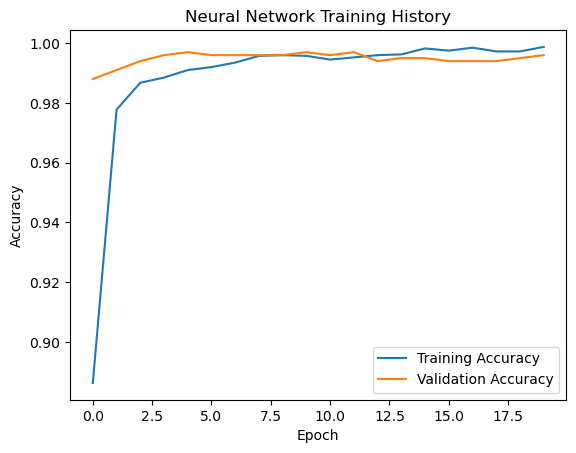

In [8]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models



Model Performance Metrics:
                   Accuracy  Precision  Recall  F1-Score
Model                                                   
Random Forest         0.999       1.00    1.00      1.00
Gradient Boosting     0.997       0.99    1.00      1.00
SVM                   0.993       0.99    0.99      0.99
Neural Network        0.996       0.99    1.00      0.99


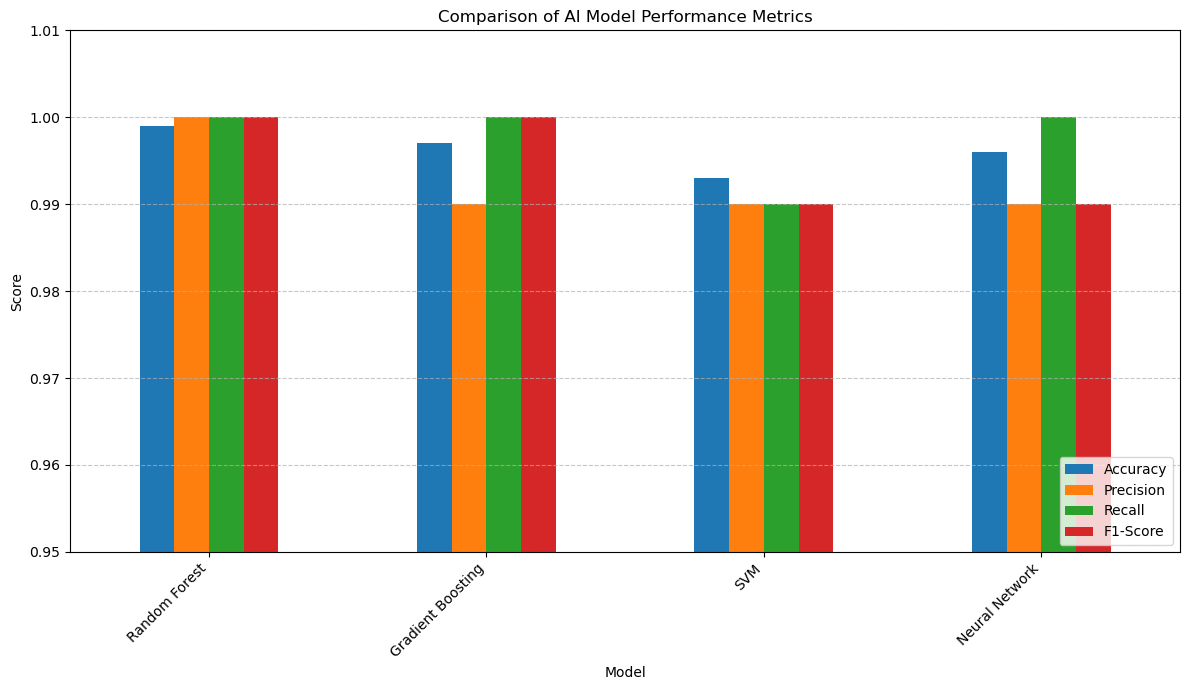

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Data extracted from the classification reports
model_names = ['Random Forest', 'Gradient Boosting', 'SVM', 'Neural Network']
accuracy = [0.999, 0.997, 0.993, 0.996]
precision = [1.00, 0.99, 0.99, 0.99]
recall = [1.00, 1.00, 0.99, 1.00]
f1_score = [1.00, 1.00, 0.99, 0.99]

# Create a DataFrame for easy plotting
metrics_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
})

# Set the index to Model names
metrics_df = metrics_df.set_index('Model')

print("Model Performance Metrics:")
print(metrics_df)

# Plotting the comparison
metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparison of AI Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.95, 1.01) # Set y-axis limits to focus on high performance scores
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()